In [38]:
import pandas as pd
import numpy as np

# Load datasets
df1 = pd.read_csv("D:\\Coding\\6th sem\\Microprocessor\\road_quality\\dataset\\bike_data_10_test1.csv")
df2 = pd.read_csv("D:\\Coding\\6th sem\\Microprocessor\\road_quality\\dataset\\bike_data_10_test2.csv")
df3 = pd.read_csv("D:\\Coding\\6th sem\\Microprocessor\\road_quality\\dataset\\bike_data_10_test3.csv")

# Add labels (Assuming test1 & test2 = smooth, test3 = rough)
df1["road_label"] = "smooth"
df2["road_label"] = "smooth"
df3["road_label"] = "rough"

# Add source column (helps debugging)
df1["source"] = "test1"
df2["source"] = "test2"
df3["source"] = "test3"

# Merge
master_df = pd.concat([df1, df2, df3], ignore_index=True)

# Convert timestamp if exists
if "Timestamp" in master_df.columns:
    master_df["Timestamp"] = pd.to_datetime(master_df["Timestamp"], errors="coerce")
    master_df = master_df.sort_values("Timestamp")

# Reset index
master_df = master_df.reset_index(drop=True)

print("Merged shape:", master_df.shape)
print(master_df.head())

Merged shape: (11594, 14)
     time        lat        lon  speed    ax   ay     az   acc_mag  gx   gy  \
0  237279  12.969813  79.164851    0.0 -2056 -804  15712  15866.33 -30  512   
1  237505  12.969813  79.164851    0.0 -2088 -764  15760  15916.06 -36  529   
2  237729  12.969813  79.164851    0.0 -2080 -804  15644  15802.14  -5  542   
3  237955  12.969813  79.164851    0.0 -2012 -788  15644  15792.52 -10  532   
4  238182  12.969813  79.164851    0.0 -2020 -772  15720  15868.04  -2  520   

    gz  label road_label source  
0   84      0     smooth  test1  
1  107      0     smooth  test1  
2   82      0     smooth  test1  
3   99      0     smooth  test1  
4  120      0     smooth  test1  


In [39]:
#clean Data
# Remove completely empty rows
master_df.dropna(how='all', inplace=True)

# Drop rows where accelerometer values are missing
master_df = master_df.dropna(subset=["ax", "ay", "az"])

# Fill small GPS gaps (if needed)
if "speed" in master_df.columns:
    master_df["speed"] = master_df["speed"].ffill()
print("After cleaning:", master_df.shape)
# Remove near-zero speed rows
if "speed" in master_df.columns:
    master_df = master_df[master_df["speed"] > 1]  # threshold can be tuned

print("After removing stationary rows:", master_df.shape)


After cleaning: (11594, 14)
After removing stationary rows: (8393, 14)


In [40]:
print(master_df["speed"].describe())

count    8393.000000
mean       20.897443
std         9.393549
min         1.170000
25%        12.430000
50%        19.690000
75%        30.090000
max        38.300000
Name: speed, dtype: float64


In [41]:
#Does rough road actually show higher vibration?


In [42]:
# First compute acceleration magnitude
import numpy as np
master_df["acc_mag"] = np.sqrt(
    master_df["ax"]**2 +
    master_df["ay"]**2 +
    master_df["az"]**2
)

# Compare variance by label
master_df.groupby("road_label")["acc_mag"].std()

road_label
rough     4190.506815
smooth    2731.398527
Name: acc_mag, dtype: float64

In [43]:
master_df.to_csv("D:\\Coding\\6th sem\\Microprocessor\\road_quality\\dataset\\processed_data\\master_cleaned_dataset.csv", index=False)

In [44]:
#Window-Level Feature Engineering

#window parameters
sampling_rate = 50   # change if needed
window_seconds = 2
window_size = sampling_rate * window_seconds

In [45]:
#Extract Features Per Window
import numpy as np
step_size = window_size // 2   # 50% overlap

windows = []

for i in range(0, len(master_df) - window_size, step_size):
    window = master_df.iloc[i:i+window_size]
    
    if window["speed"].mean() <= 1:
        continue
    
    features = {}
    
    features["road_label"] = window["road_label"].mode()[0]
    
    features["acc_mean"] = window["acc_mag"].mean()
    features["acc_std"] = window["acc_mag"].std()
    features["acc_rms"] = np.sqrt(np.mean(window["acc_mag"]**2))
    
    features["z_max"] = window["az"].max()
    features["z_min"] = window["az"].min()
    features["z_peak_to_peak"] = features["z_max"] - features["z_min"]
    
    features["speed_mean"] = window["speed"].mean()
    features["speed_std"] = window["speed"].std()
    
    windows.append(features)

feature_df = pd.DataFrame(windows)

print("New feature dataset shape:", feature_df.shape)

New feature dataset shape: (166, 9)


In [46]:
feature_df.groupby("road_label")[["acc_std", "z_peak_to_peak", "acc_rms"]].mean()

,acc_std,z_peak_to_peak,acc_rms
road_label,,,
rough,4168.990862,24066.028986,16853.556787
smooth,2661.528181,16264.845361,16308.945324


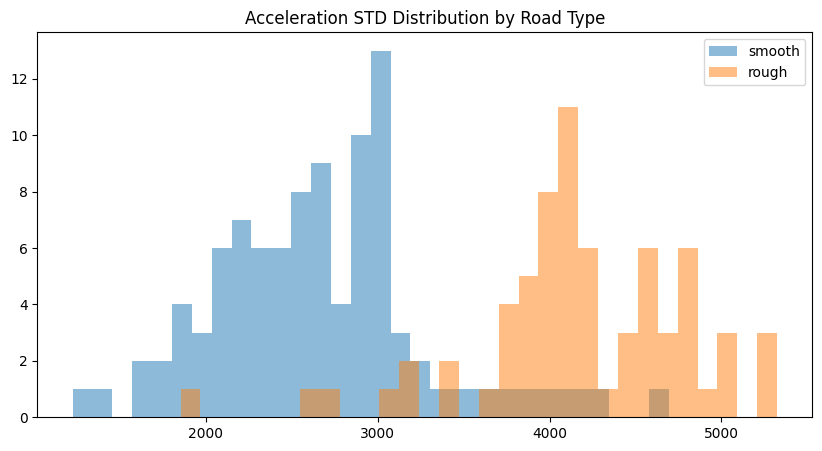

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
for label in feature_df["road_label"].unique():
    subset = feature_df[feature_df["road_label"] == label]
    plt.hist(subset["acc_std"], bins=30, alpha=0.5, label=label)

plt.legend()
plt.title("Acceleration STD Distribution by Road Type")
plt.show()

In [48]:
print(len(master_df))
print(window_size)

8393
100


In [49]:
print(feature_df["road_label"].value_counts())

road_label
smooth    97
rough     69
Name: count, dtype: int64


In [50]:
feature_df.to_csv("D:\\Coding\\6th sem\\Microprocessor\\road_quality\\dataset\\processed_data\\road_feature_windowing.csv", index=False)

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

X = feature_df.drop(columns=["road_label"])
y = feature_df["road_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.96
              precision    recall  f1-score   support

       rough       1.00      0.90      0.95        21
      smooth       0.94      1.00      0.97        29

    accuracy                           0.96        50
   macro avg       0.97      0.95      0.96        50
weighted avg       0.96      0.96      0.96        50



In [52]:
#feature importance
import pandas as pd

importances = model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(importance_df)

          Feature  Importance
1         acc_std    0.303483
6      speed_mean    0.278714
2         acc_rms    0.120331
4           z_min    0.102510
5  z_peak_to_peak    0.090784
7       speed_std    0.037205
3           z_max    0.034537
0        acc_mean    0.032436


In [53]:
X_no_speed = feature_df.drop(columns=["road_label", "speed_mean", "speed_std"])
y = feature_df["road_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X_no_speed, y, test_size=0.3, random_state=42, stratify=y
)

model2 = RandomForestClassifier(n_estimators=200, random_state=42)
model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

print("Accuracy without speed:", accuracy_score(y_test, y_pred2))
print(classification_report(y_test, y_pred2))

Accuracy without speed: 0.88
              precision    recall  f1-score   support

       rough       0.80      0.95      0.87        21
      smooth       0.96      0.83      0.89        29

    accuracy                           0.88        50
   macro avg       0.88      0.89      0.88        50
weighted avg       0.89      0.88      0.88        50



In [54]:
feature_df["predicted_label"] = model.predict(X)
feature_df.to_csv("D:\\Coding\\6th sem\\Microprocessor\\road_quality\\dataset\\processed_data\\road_feature_with_predictions.csv", index=False)